In [2]:
# ЗАДАНИЕ 1
sites = [   "GAGGTAAAC",   "TCCGTAAGC",  "CAGGTTGGA",   "ACAGTCAGC",   "TAGGTCAGC",   "CAGGTCAGC",  "CAGGTCGAT",  "CAGGTCAGC",  "CAGGTCAGC", "CAGGTTGGC"]
import numpy as np
def build_pfm(sequences):
    """Возвращает PFM как numpy array формы (4, len(sequence)): строки A,C,G,T."""
    n = len(sequences[0])
    pfm = np.zeros((4, n), dtype=int)
    mapping = {'A':0, 'C':1, 'G':2, 'T':3}
    for seq in sequences:
        for i, nt in enumerate(seq):
            pfm[mapping[nt], i] += 1
    return pfm

def pfm_to_ppm(pfm, alpha=0.1):
    N = pfm.sum(axis=0)[0]  
    return (pfm + alpha) / (N + 4 * alpha)

background = np.array([0.295, 0.205, 0.205, 0.295])  # A, C, G, T
def ppm_to_pwm(ppm, background):
    return np.log2(ppm / background[:, np.newaxis])

pfm = build_pfm(sites)
ppm = pfm_to_ppm(pfm, alpha=0.1)
pwm = ppm_to_pwm(ppm, background)

# Индексы максимумов и минимумов по столбцам
max_indices = np.argmax(pwm, axis=0)
min_indices = np.argmin(pwm, axis=0)

# Обратный словарь для перевода индексов в нуклеотиды
rev_mapping = {0:'A', 1:'C', 2:'G', 3:'T'}

max_seq = ''.join(rev_mapping[i] for i in max_indices)
min_seq = ''.join(rev_mapping[i] for i in min_indices)

# Скоры
max_score = sum(pwm[max_indices[j], j] for j in range(pwm.shape[1]))
min_score = sum(pwm[min_indices[j], j] for j in range(pwm.shape[1]))

print("PFM:\n", pfm)
print("PPM:\n", ppm)
print("PWM:\n", pwm)


print(f"Максимальный скор: {max_score:.4f}")
print(f"Последовательность: {max_seq}")
print(f"Минимальный скор: {min_score:.4f}")
print(f"Последовательность: {min_seq}")

PFM:
 [[ 1  8  1  0  0  2  7  2  1]
 [ 6  2  1  0  0  6  0  0  8]
 [ 1  0  8 10  0  0  3  8  0]
 [ 2  0  0  0 10  2  0  0  1]]
PPM:
 [[0.10576923 0.77884615 0.10576923 0.00961538 0.00961538 0.20192308
  0.68269231 0.20192308 0.10576923]
 [0.58653846 0.20192308 0.10576923 0.00961538 0.00961538 0.58653846
  0.00961538 0.00961538 0.77884615]
 [0.10576923 0.00961538 0.77884615 0.97115385 0.00961538 0.00961538
  0.29807692 0.77884615 0.00961538]
 [0.20192308 0.00961538 0.00961538 0.00961538 0.97115385 0.20192308
  0.00961538 0.00961538 0.10576923]]
PWM:
 [[-1.47979496  1.40062343 -1.47979496 -4.93922658 -4.93922658 -0.54690915
   1.21052054 -0.54690915 -1.47979496]
 [ 1.5166018  -0.02181811 -0.95470391 -4.41413553 -4.41413553  1.5166018
  -4.41413553 -4.41413553  1.92571447]
 [-0.95470391 -4.41413553  1.92571447  2.24407595 -4.41413553 -4.41413553
   0.54006078  1.92571447 -4.41413553]
 [-0.54690915 -4.93922658 -4.93922658 -4.93922658  1.71898491 -0.54690915
  -4.93922658 -4.93922658 -1.479

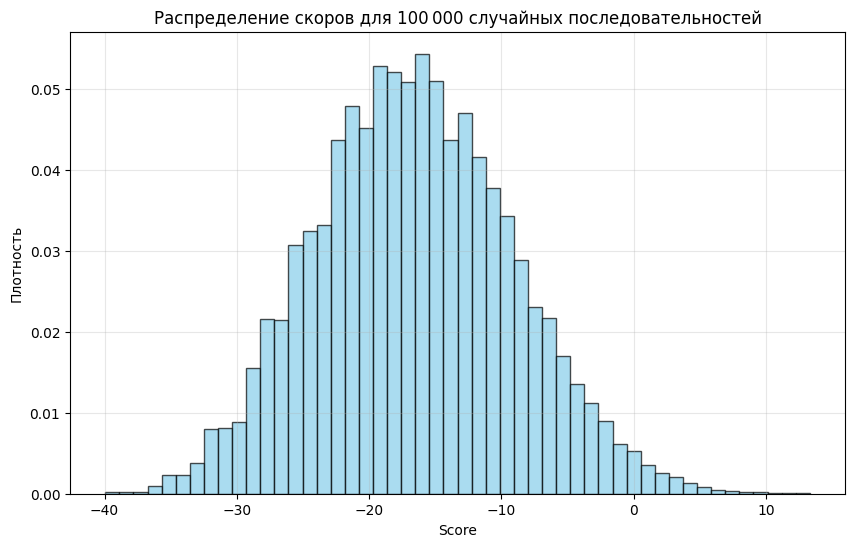

Threshold: 10.85


In [3]:
# ЗАДАНИЕ 3
import matplotlib.pyplot as plt
# 1. генератор случайных последовательностей
def generate_random_sequences(n, L, bg_probs):
    # bg_probs = [Р(A), Р(C), Р(G), Р(T)]
    nucleotides = np.array([0,1,2,3])  # индексы A,C,G,T
    # Генерируем матрицу индексов размером (n, L)
    seqs = np.random.choice(nucleotides, size=(n, L), p=bg_probs)
    return seqs

seqs = generate_random_sequences(100000, 9, [0.295, 0.205, 0.205, 0.295])

# 2. Функция для вычисления скора и подсчет скора
def score_sequence(seq_indices, pwm):
    """Сумма весов PWM для последовательности индексов."""
    score = 0.0
    for pos, nt in enumerate(seq_indices):
        score += pwm[nt, pos]
    return score

scores = np.zeros(100000)
for i in range(100000):
    scores[i] = score_sequence(seqs[i], pwm)

# 3. Построение гистограммы распределения 
plt.figure(figsize=(10, 6))
plt.hist(scores, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Score')
plt.ylabel('Плотность')
plt.title('Распределение скоров для 100 000 случайных последовательностей')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Функция get_pvalue  и рассчет threshold
def get_pvalue(score, scores):
    return np.mean(scores >= score)
sorted_scores = np.sort(scores)[::-1]         
threshold_top10 = sorted_scores[9]             
p_top10 = get_pvalue(threshold_top10, scores)
print(f"Threshold: {threshold_top10:.2f}")



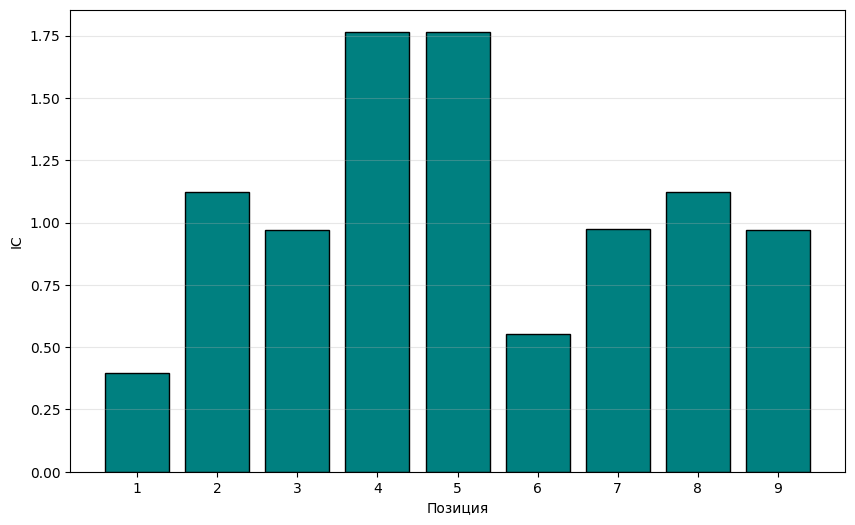

IC для каждой позиции:
Позиция 1: 0.3969
Позиция 2: 1.1242
Позиция 3: 0.9691
Позиция 4: 1.7657
Позиция 5: 1.7657
Позиция 6: 0.5520
Позиция 7: 0.9747
Позиция 8: 1.1242
Позиция 9: 0.9691


In [5]:
# ЗАДАНИЕ 4


def entropy(probs):
    probs = np.clip(probs, 1e-12, 1)
    return -np.sum(probs * np.log2(probs))

H = np.apply_along_axis(entropy, axis=0, arr=ppm)
IC = 2 - H

# Построение диаграммы
positions = np.arange(1, len(IC)+1)
plt.figure(figsize=(10, 6))
plt.bar(positions, IC, color='teal', edgecolor='black')
plt.xlabel('Позиция')
plt.ylabel('IC')
plt.xticks(positions)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("IC для каждой позиции:")
for i, ic in enumerate(IC):
    print(f"Позиция {i+1}: {ic:.4f}")

Самые большие значения IC наблюдаются для позиций 4 и 5, то есть данные позиции являются кор-мотивами. Такое предположение можно выдвинуть и ранее, исходя из визуального осмотра последовательностей.

In [18]:
# ЗАДАНИЕ 5
""" Для задания использовалась последовательность
Homo sapiens peroxidasin (PXDN), transcript variant 1, mRNA (6901 bp)"""
# 1. загрузка последовательности
from Bio import SeqIO
record = SeqIO.read ("sequence.fasta", "fasta")
seq = record.seq
L = len(seq)


# подсчет динуклеотидов
nt_index = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
counts = np.zeros((4, 4), dtype=int)  # счётчик переходов i->j

for i in range(L-1):
    a = seq[i]
    b = seq[i+1]
    if a in nt_index and b in nt_index:
        counts[nt_index[a], nt_index[b]] += 1

print("\nМатрица частот динуклеотидов (строки: A,C,G,T; столбцы: A,C,G,T):")
print(counts)

# 3. Матрица переходов P (вероятности)
row_sums = counts.sum(axis=1)

P = np.zeros((4, 4))
for i in range(4):
    if row_sums[i] > 0:
        P[i, :] = counts[i, :] / row_sums[i]
    else:
        P[i, :] = 0 

print("\nМатрица переходов P (вероятности i->j):")
print(np.round(P, 4))

# Проверка сумм по строкам
row_sums_P = P.sum(axis=1)
print("\nСуммы по строкам:", np.round(row_sums_P, 6))

# 4. Стационарное распределение π
eigvals, eigvecs = np.linalg.eig(P.T)

idx = np.argmin(np.abs(eigvals - 1))
pi = eigvecs[:, idx].real
pi = pi / pi.sum()  # нормировка
print("\nСтационарное распределение π:")
for nt, p in zip(['A','C','G','T'], pi):
    print(f"{nt}: {p:.6f}")

# 5. Наблюдаемые частоты отдельных нуклеотидов

nt_counts = np.array([seq.count('A'), seq.count('C'), seq.count('G'), seq.count('T')])
observed_freq = nt_counts / L
print("\nНаблюдаемые частоты нуклеотидов:")
for nt, f in zip(['A','C','G','T'], observed_freq):
    print(f"{nt}: {f:.6f}")

# Сравнение
print("\nСравнение стационарного распределения и наблюдаемых частот:")
diff = pi - observed_freq
print("Разность (π - наблюдаемая):", np.round(diff, 6))



Матрица частот динуклеотидов (строки: A,C,G,T; столбцы: A,C,G,T):
[[412 445 459 313]
 [591 555 337 445]
 [458 517 534 365]
 [169 411 543 349]]

Матрица переходов P (вероятности i->j):
[[0.2529 0.2732 0.2818 0.1921]
 [0.3065 0.2879 0.1748 0.2308]
 [0.2444 0.2759 0.285  0.1948]
 [0.1148 0.2792 0.3689 0.2371]]

Суммы по строкам: [1. 1. 1. 1.]

Стационарное распределение π:
A: 0.236130
C: 0.279298
G: 0.271331
T: 0.213240

Наблюдаемые частоты нуклеотидов:
A: 0.236095
C: 0.279258
G: 0.271437
T: 0.213210

Сравнение стационарного распределения и наблюдаемых частот:
Разность (π - наблюдаемая): [ 3.50e-05  4.00e-05 -1.06e-04  3.00e-05]


Вывод: данная последовательность хорошо описывается стационарной марковской цепью первого порядка.


Стационарное распределение π:
 [0.23613  0.279298 0.271331 0.21324 ]


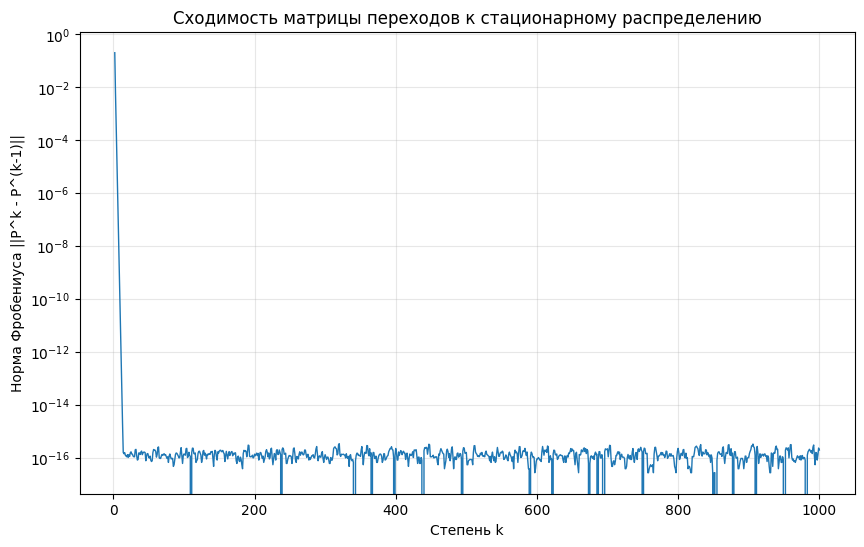


Матрица P^1000:
[[0.23613  0.279298 0.271331 0.21324 ]
 [0.23613  0.279298 0.271331 0.21324 ]
 [0.23613  0.279298 0.271331 0.21324 ]
 [0.23613  0.279298 0.271331 0.21324 ]]

Проверка: разность между строками P^1000 и стационарным распределением:
Строка 0: max |diff| = 6.38e-15
Строка 1: max |diff| = 6.33e-15
Строка 2: max |diff| = 6.38e-15
Строка 3: max |diff| = 6.38e-15

Максимальное различие между строками P^1000:
Максимальное расхождение между любыми двумя строками: 5.55e-17


In [20]:
# ЗАДАНИЕ 6
# Стационарное распределение (для последующей проверки)
eigvals, eigvecs = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigvals - 1))
pi = eigvecs[:, idx].real
pi = pi / pi.sum()
print("\nСтационарное распределение π:\n", np.round(pi, 6))

# ------------------------------------------------------------
# 2. Возведение в степень и вычисление норм разности
# ------------------------------------------------------------
k_max = 1000
norms = []          # для хранения норм ||P^k - P^(k-1)||
P_prev = None

for k in range(1, k_max+1):
    P_k = np.linalg.matrix_power(P, k)
    if k > 1:
        diff = P_k - P_prev
        norm = np.linalg.norm(diff, 'fro')
        norms.append(norm)
    P_prev = P_k

    if k == k_max:
        P_final = P_k

# ------------------------------------------------------------
# 3. График стабилизации
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(range(2, k_max+1), norms, linewidth=1)
plt.xlabel('Степень k')
plt.ylabel('Норма Фробениуса ||P^k - P^(k-1)||')
plt.title('Сходимость матрицы переходов к стационарному распределению')
plt.yscale('log')  
plt.grid(True, alpha=0.3)
plt.savefig('convergence.png')
plt.show()

# ------------------------------------------------------------
# 4. Проверка, что строки P^1000 равны π
# ------------------------------------------------------------
print("\nМатрица P^1000:")
print(np.round(P_final, 6))

print("\nПроверка: разность между строками P^1000 и стационарным распределением:")
for i in range(4):
    diff_row = P_final[i, :] - pi
    print(f"Строка {i}: max |diff| = {np.max(np.abs(diff_row)):.2e}")

# Также можно показать, что все строки одинаковы
print("\nМаксимальное различие между строками P^1000:")
row_diffs = []
for i in range(4):
    for j in range(i+1, 4):
        diff = np.max(np.abs(P_final[i,:] - P_final[j,:]))
        row_diffs.append(diff)
print(f"Максимальное расхождение между любыми двумя строками: {max(row_diffs):.2e}")

In [25]:
# ЗАДАЧА 8

import random

# 1. Функция generate_sequence
def generate_sequence(P, length, start_state):
    """
    Генерирует последовательность длины length, начиная с нуклеотида start_state.
    P: матрица переходов 4x4 (строки: A,C,G,T в этом порядке)
    start_state: индекс начального нуклеотида (0=A,1=C,2=G,3=T)
    """
    nucleotides = ['A', 'C', 'G', 'T']
    seq = [nucleotides[start_state]]
    current = start_state
    for _ in range(length - 1):
        next_nt = np.random.choice(4, p=P[current])
        seq.append(nucleotides[next_nt])
        current = next_nt
    return ''.join(seq)


# 2. Генерация  10 последовательностей длиной 1000 нуклеотидов каждая
generated_seqs = []
for _ in range(10):
    start = np.random.randint(0, 4)
    generated_seqs.append(generate_sequence(P, 1000, start))

# 3. Подсчёт эмпирических частот динуклеотидов для каждой последовательности и усреднение
def compute_transition_matrix(seq):
    counts = np.zeros((4, 4), dtype=int)
    for i in range(len(seq)-1):
        a = seq[i]
        b = seq[i+1]
        if a in nt_index and b in nt_index:
            counts[nt_index[a], nt_index[b]] += 1
    row_sums = counts.sum(axis=1)
    P_emp = np.zeros((4, 4))
    for i in range(4):
        if row_sums[i] > 0:
            P_emp[i, :] = counts[i, :] / row_sums[i]
    return P_emp

emp_matrices = [compute_transition_matrix(seq) for seq in generated_seqs]
# Усредняем
P_avg = np.mean(emp_matrices, axis=0)
print("Средняя эмпирическая матрица переходов:\n", np.round(P_avg, 4))


# Вычислим разность
diff = P - P_avg
print("Средняя абсолютная ошибка:", np.mean(np.abs(diff)))
print("Максимальная абсолютная ошибка:", np.max(np.abs(diff)))



Средняя эмпирическая матрица переходов:
 [[0.2545 0.2867 0.2726 0.1862]
 [0.3207 0.2785 0.1653 0.2355]
 [0.2281 0.2813 0.2894 0.2012]
 [0.1051 0.2879 0.3683 0.2387]]
Средняя абсолютная ошибка: 0.00758504074679226
Максимальная абсолютная ошибка: 0.01634600523175589


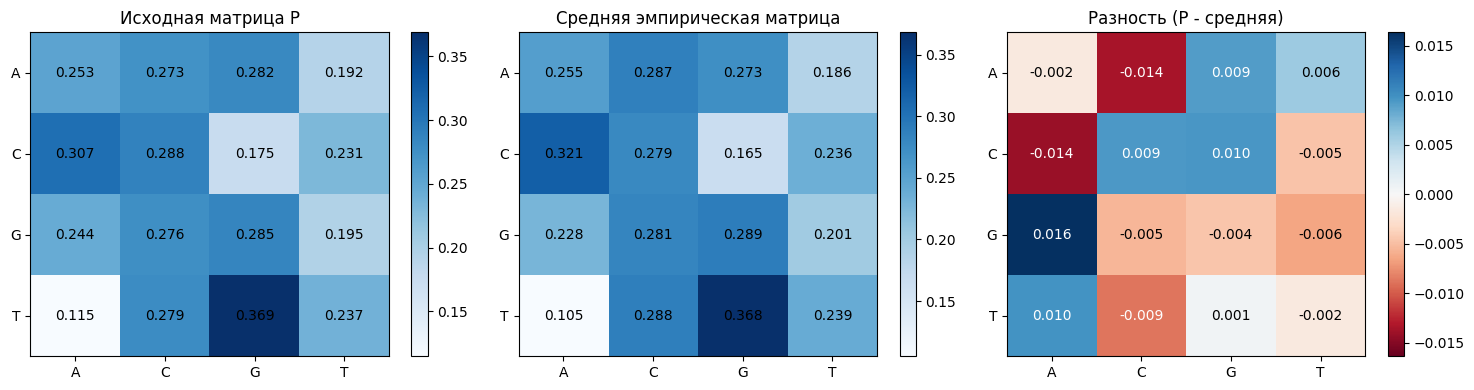

In [27]:


def plot_heatmap(ax, data, title, cmap='Blues', fmt='.3f', vmin=None, vmax=None, center=None):
    """
    Рисует тепловую карту на указанной оси ax.
    - data: матрица 4x4
    - title: заголовок
    - cmap: цветовая карта
    - fmt: формат чисел в ячейках
    - vmin, vmax: границы цветовой шкалы
    - center: если задан, создаёт дивергентную шкалу с центром в этом значении
    """
    if center is not None:
        # Автоматически подбираем симметричные границы вокруг центра
        abs_max = max(np.abs(data.min()), np.abs(data.max()))
        vmin = -abs_max
        vmax = abs_max
        im = ax.imshow(data, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    else:
        im = ax.imshow(data, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    
    # Цветовая шкала
    plt.colorbar(im, ax=ax)
    
    # Настройка меток осей
    nt_labels = ['A', 'C', 'G', 'T']
    ax.set_xticks(np.arange(len(nt_labels)))
    ax.set_yticks(np.arange(len(nt_labels)))
    ax.set_xticklabels(nt_labels)
    ax.set_yticklabels(nt_labels)
    
    # Добавление числовых значений в ячейки
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data[i, j]
            # Выбор цвета текста для читаемости
            text_color = 'white' if np.abs(value) > (vmax/2 if vmax else 0.5) else 'black'
            ax.text(j, i, format(value, fmt), ha='center', va='center', color=text_color)
    
    ax.set_title(title)

# Пример использования с матрицами P, P_avg, diff
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_heatmap(axes[0], P, 'Исходная матрица P', cmap='Blues')
plot_heatmap(axes[1], P_avg, 'Средняя эмпирическая матрица', cmap='Blues')
plot_heatmap(axes[2], diff, 'Разность (P - средняя)', cmap='RdBu', center=0)

plt.tight_layout()
plt.savefig('comparison_heatmaps.png')
plt.show()